# 2.4.1 误差与网格细化

## 学习目标与先修知识

能在相同初值问题（initial value problem）上测量最大绝对误差（maximum absolute error），解释欧拉法（forward Euler method）的典型一阶收敛（first-order convergence），并识别观测收敛阶（observed order of convergence）不能使用的情形。

先修：恒定输入（input）解析解（analytical solution）、有限求和与指数函数（exponential function）；上一章的单位和时间尺度（time scale）。 [复习上一节](../03-连续时间与一阶微分方程/02-平衡位置与靠近速度.ipynb)。

## 具体问题

一条平滑数值曲线离正确模型（model）解还有多远？把步长减半后，误差应怎样变化，才支持“这次模拟逐渐可信”的判断？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
for h in [1,.5,.25]:
    value=0.0
    for _ in range(round(2/h)):value+=h*(1-.5*value)
    exact=2*(1-math.exp(-1))
    print(f'h={h:g} T, 终点绝对误差={abs(value-exact):.8f} U')

h=1 T, 终点绝对误差=0.23575888 U
h=0.5 T, 终点绝对误差=0.10294638 U
h=0.25 T, 终点绝对误差=0.04854105 U


## 模型假设

模型仍为 A′=u−kA。欧拉法在每一步用左端变化率延伸直线，A[n+1]=A[n]+h(u−kA[n])。本节使用可整除共同终点的均匀网格，先选 kh≤1 的正常范围，避免混入不稳定失败。A0、u、k 和观察区间在网格对照中保持一致。

## 数学解释与推导

在网格 $t_i=ih$ 上，用独立解析解定义
$$E(h)=\max_i|A_i-A(t_i)|.$$
终点误差只是其中一项；一条曲线中间也可能偏离更多。绝对误差仍用 U，不能同相对误差或收支（mass balance）残差（residual）混用。

为什么通常是一阶？当 $k>0$，从精确起点 $A=A(t)$ 出发的完整精确一步为
$$A(t+h)=Ae^{-kh}+\frac{u}{k}(1-e^{-kh}).$$
小 $h$ 下，衰减因子为 $e^{-kh}=1-kh+k^2h^2/2+O(h^3)$；恒定输入项也要展开：
$$\frac{u}{k}(1-e^{-kh})=uh-\frac{uk}{2}h^2+O(h^3).$$
合并后，精确一步减去 Euler 一步 $A+h(u-kA)$ 得到
$$A(t+h)-[A+h(u-kA)]=\frac{k^2A-ku}{2}h^2+O(h^3),$$
因此从精确起点出发的一步差异为 $O(h^2)$。当 $k=0$，模型为 $A'=u$，完整一步恰是 $A+uh$，本节 Euler 更新精确；不能把含 $1/k$ 的式子直接代入 $k=0$。这里 O(h²) 表示足够小时误差可被常数乘 h² 控制；不是宣称误差恰好等于 h²。

固定总时间内约有 T/h 步。令数值误差（numerical error）为 ε，在本线性模型中它满足 $\varepsilon_{n+1}=(1-kh)\varepsilon_n+d_n$，其中 $|d_n|\le Ch^2$。当 $|1-kh|\le1$ 且初始误差为零，把递推展开，有 $|\varepsilon_N|\le NCh^2\le CT h$，说明一阶收敛的来源。更一般问题还需要光滑性和误差传播条件。

若 $E(h)\approx Ch^p$，减半步长得到
$$p_{\rm obs}=\log_2\frac{E(h)}{E(h/2)}.$$
这是当前几个网格上的观测收敛阶，不是证明。零清除线性轨迹（trajectory）可能被精确求出，两个零误差不能取比值；浮点舍入主导时也不能据此估计方法阶数。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def euler(A0, u, k, h, steps):
    amounts = [A0]
    residuals = []
    for _ in range(steps):
        before = amounts[-1]
        incoming = h * u
        removed = h * k * before
        after = before + incoming - removed
        amounts.append(after)
        residuals.append(after - before - incoming + removed)
    return amounts, residuals

def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

def grid_errors(A0, u, k, step_sizes, end):
    errors = []
    for h in step_sizes:
        steps = round(end / h)
        amounts, _ = euler(A0, u, k, h, steps)
        errors.append(max(abs(a - exact_amount(i * h, u, k, A0))
                          for i, a in enumerate(amounts)))
    return errors

def observed_orders(errors):
    import math
    return [math.log2(a / b) for a, b in zip(errors, errors[1:])]

## 对照实验

| h / T | 最大误差 / U | 与下一网格的观测收敛阶 |
| --- | --- | --- |
| 0.5 | 0.102946 | 1.08462 |
| 0.25 | 0.0485411 | 1.03977 |
| 0.125 | 0.0236106 | 1.01932 |
| 0.0625 | 0.0116483 | — |

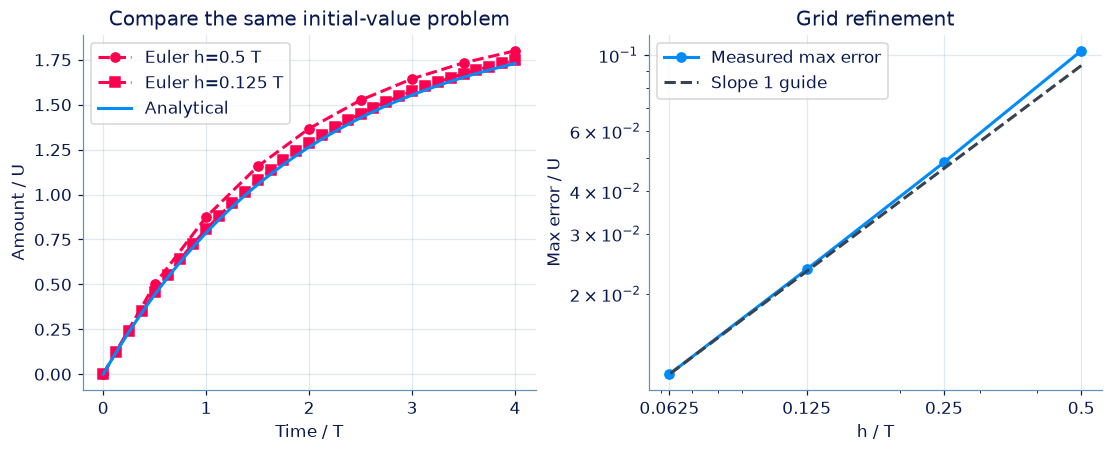

In [4]:
hs=[.5,.25,.125,.0625]
errors=grid_errors(0,1,.5,hs,4)
orders=observed_orders(errors)
display(Markdown(show_table(['h / T','最大误差 / U','与下一网格的观测收敛阶'],[(h,e,orders[i] if i<len(orders) else '—') for i,(h,e) in enumerate(zip(hs,errors))])))
fig,axes=plt.subplots(1,2,figsize=(10,4))
for h,mark in [(.5,'o'),(.125,'s')]:
    amounts,_=euler(0,1,.5,h,round(4/h));times=np.arange(len(amounts))*h
    axes[0].plot(times,amounts,mark+'--',color='#ff0051',label=f'Euler h={h} T')
t=np.linspace(0,4,201);axes[0].plot(t,exact_series(0,1,.5,t),color='#008bfb',label='Analytical')
axes[0].set(xlabel='Time / T',ylabel='Amount / U',title='Compare the same initial-value problem');axes[0].legend()
axes[1].loglog(hs,errors,'o-',label='Measured max error')
axes[1].loglog(hs,[errors[-1]*h/hs[-1] for h in hs],'--',color='#384251',label='Slope 1 guide')
axes[1].set(xlabel='h / T',ylabel='Max error / U',title='Grid refinement')
from matplotlib.ticker import NullFormatter
axes[1].set_xticks(hs, [str(h) for h in hs]);axes[1].xaxis.set_minor_formatter(NullFormatter())
axes[1].legend();plt.show()

## 结果解释

误差随这组步长减半而下降，观测收敛阶接近 1，与推导一致。左图较粗轨迹也很平滑，却有可测量偏差；判断精度需要数值参照。若目标精度尚未达到，应继续细化或选更合适方法，并重新检查计算成本和误差来源。

### 独立核对

实际使用成熟求解器时，容差控制也不是无需验证的保证。SciPy 的 `solve_ivp` 文档说明误差容差与方法选择；此处先把最小循环和核验完整展示，不引入黑箱依赖。

In [5]:
assert all(a>b>0 for a,b in zip(errors,errors[1:]))
assert all(.8<p<1.2 for p in orders)
assert max(grid_errors(3,2,0,[1,.5,.25],4))<1e-12
for h in [.5,.25]:
    values,_=euler(0,1,.5,h,round(4/h))
    closed=[2*(1-(1-.5*h)**n) for n in range(len(values))]
    np.testing.assert_allclose(values,closed,atol=1e-12)
print('独立递推闭式、解析参考、网格细化和零误差边界通过。')

独立递推闭式、解析参考、网格细化和零误差边界通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-04-数值模拟、误差与迁移/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把误差变成一张可比较的表

对同一恒定输入（input）初值问题（initial value problem），用给定的多个步长分别做显式欧拉法（forward Euler method）更新。对各自全部网格点与解析解（analytical solution）比较，返回最大绝对误差（maximum absolute error）。

**函数与代码模板**

```python
def solve(
    A0: float,
    u: float,
    k: float,
    step_sizes: list[float],
    end: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 初始所追踪物质总量（tracked amount）。 | U |
| `u` | `float` | 恒定输入。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `step_sizes` | `list[float]` | 逐一独立尝试的步长。 | T |
| `end` | `float` | 共同终点。 | T |

**返回值**

直接返回 errors（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `errors` | `list[float]` | 按步长顺序返回网格最大绝对误差。 | U |

**计算规则**

每个 h 都从同一 A0 开始；steps=round(end/h)；比较 i=0…steps 的 A[i] 与恒定输入解析解。k=0 用线性解。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0 ≤ A0,u ≤ 20；0 ≤ k ≤ 2；0 < end ≤ 20；step_sizes 长度 1—10；每个 end/h 为正整数（误差 <1e−10），最多 10000 步。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 初始所追踪物质总量（tracked amount）。 | 0 | U |
| u | 恒定输入。 | 1 | U/T |
| k | 清除系数（elimination rate constant）。 | 0.5 | 1/T |
| step_sizes | 逐一独立尝试的步长。 | [1, 0.5, 0.25] | T |
| end | 共同终点。 | 2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 0
u = 1
k = 0.5
step_sizes = [1, 0.5, 0.25]
end = 2

result = solve(A0, u, k, step_sizes, end)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| errors | 按步长顺序返回网格最大绝对误差。 | [0.23575888234288467, 0.10294638234288467, 0.04854105073125137] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.23575888234288467,
                   0.10294638234288467,
                   0.04854105073125137]
```

**样例解释**

h=1 时轨迹（trajectory） [0,1,1.5]，误差约为 [0,0.2130613,0.2357589] U，取最大值；其他 h 重新计算。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：把误差变成一张可比较的表](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-errors)

### 第 2 题 · Python 计算题：从误差缩小比例估计阶数

已按 h、h/2、h/4…得到正的最大误差序列。返回相邻两项对应的观测收敛阶（observed order of convergence） p=log2(Eh/Eh/2)。

**函数与代码模板**

```python
def solve(
    errors: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `errors` | `list[float]` | 随步长逐次减半得到的正误差。 | U |

**返回值**

直接返回 orders（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `orders` | `list[float]` | 每对相邻误差的观测收敛阶，长度少一。 | 1 |

**计算规则**

按原顺序返回 log2(errors[i]/errors[i+1])；允许误差增大而产生负观测收敛阶，不截断、不取整。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 1 ≤ len(errors) ≤ 100；1e−12 ≤ errors[i] ≤ 1e6；步长确为依次减半。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| errors | 随步长逐次减半得到的正误差。 | [0.2, 0.1, 0.05] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
errors = [0.2, 0.1, 0.05]

result = solve(errors)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| orders | 每对相邻误差的观测收敛阶，长度少一。 | [1.0, 1.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 1.0]
```

**样例解释**

每次误差减半，比例为 2，因此两个观测收敛阶均为 1。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：从误差缩小比例估计阶数](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-orders)

### 第 3 题 · 多项选择题：一次更新舍弃了什么

欧拉法（forward Euler method）在整个步长 h 内使用段首变化率 f(t,A)。对于光滑解，一步从精确起点出发的遗漏量通常是 O(h²)。哪些结论合理？

- **A.** 固定总时间内约有 1/h 次更新，稳定条件下全局误差通常为 O(h)。
- **B.** 只要一步误差是 O(h²)，全局一定二阶。
- **C.** 结果还受到舍入误差（round-off error）影响。
- **D.** 光滑性和误差传播条件可以忽略。

[作答：一次更新舍弃了什么](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-truncation)

### 第 4 题 · 单项选择题：怎样公平地细化网格

比较 h=0.5 与 h=0.25 的误差，哪种安排合理？

- **A.** 两次使用同一初值（initial condition）、参数（parameter）、输入（input）和观察区间。
- **B.** 第二次从第一次终点开始。
- **C.** 第二次同时改变 k，让曲线看起来接近。
- **D.** 只比较两幅图是否足够平滑。

[作答：怎样公平地细化网格](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-fair-refinement)

### 第 5 题 · 单项选择题：误差为零还能取对数吗

零清除且输入（input）恒定时，欧拉法（forward Euler method）给出线性精确结果（忽略浮点舍入）。误差表 E(h)=E(h/2)=0。怎样处理观测收敛阶（observed order of convergence）？

- **A.** 认定方法无限阶。
- **B.** 报告此例不能用误差比估计阶数，另选非平凡衰减实验。
- **C.** 强行算 log2(0/0)。
- **D.** 把零改为一个任意正数即可得到证明。

[作答：误差为零还能取对数吗](http://127.0.0.1:8000/chapters/02-04-%E6%95%B0%E5%80%BC%E6%A8%A1%E6%8B%9F%E3%80%81%E8%AF%AF%E5%B7%AE%E4%B8%8E%E8%BF%81%E7%A7%BB/practice/?question=p02-zero-error)

**进一步阅读**

[SciPy solve_ivp 官方文档](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)：进一步了解误差容差与方法；本节没有调用该求解器。